In [1]:
#-----------------------------------【Install packages】----------------------------------

import scanpy as sc
import networkx as nx
import community   # pip install python-louvain
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# adata_hvg = sc.read_h5ad("/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_protein_coding_genes/Adata/My_merge_PCA_2000HVG(protein_coding).h5ad")

In [ ]:
# print(adata_hvg)

AnnData object with n_obs × n_vars = 232477 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_pca'
    varm: 'PCs'



處理 k = 10


/staging/biology/jane0528/miniconda3/envs/scrublet_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/staging/biology/jane0528/ipykernel_2819481/1156312938.py:12: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_hvg, key_added=col, random_state=42)


clusters: 27, modularity: 0.8835

處理 k = 15
clusters: 26, modularity: 0.8808

處理 k = 20
clusters: 27, modularity: 0.8784

處理 k = 25
clusters: 26, modularity: 0.8765

處理 k = 30
clusters: 26, modularity: 0.8741

處理 k = 35
clusters: 26, modularity: 0.8732

處理 k = 40
clusters: 26, modularity: 0.8729


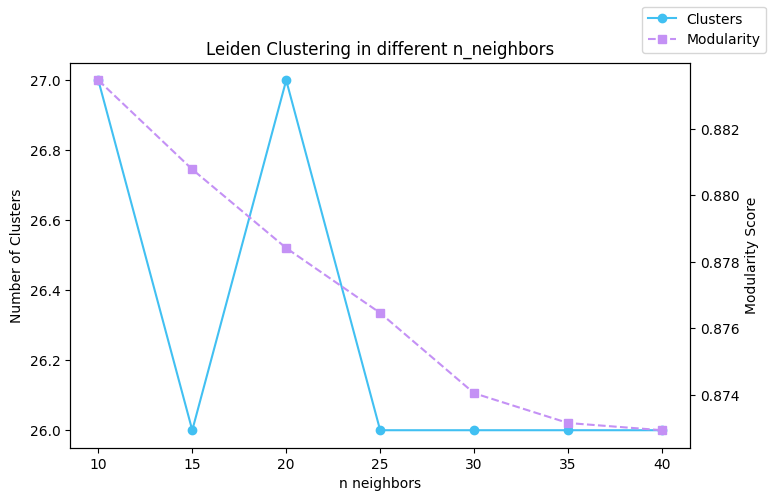

In [ ]:
# summary = []
# nn_list = [10, 15, 20, 25, 30, 35, 40]

# for k in nn_list:
#     print(f"\n處理 k = {k}")
        
#     # 建立鄰近圖 (knn)
#     #使用PC50
#     sc.pp.neighbors(adata_hvg, n_neighbors=k, n_pcs=50, use_rep="X_pca")
        
#     # 執行 Leiden clustering
#     col = f"leiden_nn{k}"
#     sc.tl.leiden(adata_hvg, key_added=col, random_state=0)
        
#     # 計算分群資訊
#     labels = adata_hvg.obs[col]
#     label_dict = dict(zip(range(len(labels)), labels.astype(str)))

#     # 用 connectivities 建 NetworkX graph
#     conn = adata_hvg.obsp["connectivities"]
#     G = nx.Graph(conn)

#     # 計算 modularity
#     modularity = community.modularity(label_dict, G)

#     n_cls = labels.nunique()
#     summary.append({"n_nei": k, "n_clusters": n_cls, "modularity": modularity})
#     print(f"clusters: {n_cls}, modularity: {modularity:.4f}")
    
# df = pd.DataFrame(summary) 

# import matplotlib.pyplot as plt

# # 畫群數 & modularity
# fig, ax1 = plt.subplots(figsize=(8, 5))
# ax1.plot(df['n_nei'], df["n_clusters"], "o-", label="Clusters", color='#41C0F2')
# ax1.set_xlabel("n neighbors")
# ax1.set_ylabel("Number of Clusters")
# ax2 = ax1.twinx()  # 共享x軸
# ax2.plot(df['n_nei'], df["modularity"], "s--", label="Modularity", color='#C491F5')
# ax2.set_ylabel("Modularity Score")
# plt.title(f"Leiden Clustering in different n_neighbors")
# fig.legend()
# plt.show()


處理 res = 0.6
clusters: 21, silhouette score: 0.1401

處理 res = 0.8
clusters: 24, silhouette score: 0.1273

處理 res = 1.0
clusters: 28, silhouette score: 0.0940

處理 res = 1.2
clusters: 28, silhouette score: 0.0936

處理 res = 1.5
clusters: 33, silhouette score: 0.0938
Best resolution by silhouette score: 0.6


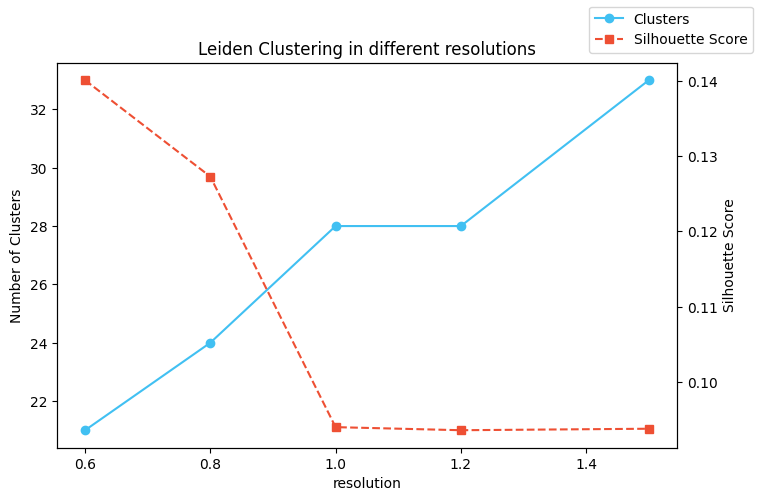

In [ ]:
# # ---------------------------- 尋找最佳 resolution(n=20) ----------------------------
# from sklearn.metrics import silhouette_score

# best_nn = 20
# resolutions = [0.6, 0.8, 1.0, 1.2, 1.5]
# silhouette_scores = []
# summary_res = []

# sc.pp.neighbors(adata_hvg, n_neighbors=best_nn, n_pcs=50, use_rep='X_pca')

# for res in resolutions:
#     print(f"\n處理 res = {res}")
#     sc.tl.leiden(adata_hvg, resolution=res, key_added=f'leiden_res{res}')
#     score = silhouette_score(adata_hvg.obsm['X_pca'], adata_hvg.obs[f'leiden_res{res}'])
#     silhouette_scores.append((res, score))

#     n_cls = adata_hvg.obs[f'leiden_res{res}'].nunique()
#     summary_res.append({"resolution": res, "n_clusters": n_cls, "silhouette score": score})
#     print(f"clusters: {n_cls}, silhouette score: {score:.4f}")

# best_res = sorted(silhouette_scores, key=lambda x: x[1], reverse=True)[0][0]
# print("Best resolution by silhouette score:", best_res)

# df = pd.DataFrame(summary_res)

# fig, ax1 = plt.subplots(figsize=(8, 5))
# ax1.plot(df['resolution'], df["n_clusters"], "o-", label="Clusters", color='#41C0F2')
# ax1.set_xlabel("resolution")
# ax1.set_ylabel("Number of Clusters")
# ax2 = ax1.twinx()  # 共享x軸
# ax2.plot(df['resolution'], df["silhouette score"], "s--", label="Silhouette Score", color="#EE4F33")
# ax2.set_ylabel("Silhouette Score")
# plt.title(f"Leiden Clustering in different resolutions")
# fig.legend()
# plt.show()

In [ ]:
# # ---------------------------- 尋找最佳 resolution(n=25) ----------------------------
# from sklearn.metrics import silhouette_score

# best_nn = 25
# resolutions = [0.6, 0.8, 1.0, 1.2, 1.5]
# silhouette_scores = []
# summary_res = []

# sc.pp.neighbors(adata_hvg, n_neighbors=best_nn, n_pcs=50, use_rep='X_pca')

# for res in resolutions:
#     print(f"\n處理 res = {res}")
#     sc.tl.leiden(adata_hvg, resolution=res, key_added=f'leiden_res{res}')
#     score = silhouette_score(adata_hvg.obsm['X_pca'], adata_hvg.obs[f'leiden_res{res}'])
#     silhouette_scores.append((res, score))

#     n_cls = adata_hvg.obs[f'leiden_res{res}'].nunique()
#     summary_res.append({"resolution": res, "n_clusters": n_cls, "silhouette score": score})
#     print(f"clusters: {n_cls}, silhouette score: {score:.4f}")

# best_res = sorted(silhouette_scores, key=lambda x: x[1], reverse=True)[0][0]
# print("Best resolution by silhouette score:", best_res)

# df = pd.DataFrame(summary_res)

# fig, ax1 = plt.subplots(figsize=(8, 5))
# ax1.plot(df['resolution'], df["n_clusters"], "o-", label="Clusters", color='#41C0F2')
# ax1.set_xlabel("resolution")
# ax1.set_ylabel("Number of Clusters")
# ax2 = ax1.twinx()  # 共享x軸
# ax2.plot(df['resolution'], df["silhouette score"], "s--", label="Silhouette Score", color="#EE4F33")
# ax2.set_ylabel("Silhouette Score")
# plt.title(f"Leiden Clustering in different resolutions")
# fig.legend()
# plt.show()

In [ ]:
# adata_hvg

AnnData object with n_obs × n_vars = 232477 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'leiden_nn10', 'leiden_nn15', 'leiden_nn20', 'leiden_nn25', 'leiden_nn30', 'leiden_nn35', 'leiden_nn40', 'leiden_res0.6', 'leiden_res0.8', 'leiden_res1.0', 'leiden_res1.2', 'leiden_res1.5'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    uns: 'neighbors', 'leiden_nn10', 'leiden_nn15', 'leiden_nn20', 'leiden_nn25', 'leiden_nn30', 'leiden_nn35', 'leiden_nn40', 'leiden_res0.6', 'leiden_res0.8', 'leiden_res1.0', 'leiden_res1.2', 'leiden_res1.5'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [ ]:
#adata_hvg.write_h5ad("/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_protein_coding_genes/Adata/My_merge_PCA_2000HVG(Leiden_pcALL_parameters).h5ad")

In [ ]:
adata_hvg= sc.read_h5ad("/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_protein_coding_genes/Adata/My_merge_PCA_2000HVG(Leiden_pcALL_parameters).h5ad")

In [ ]:
# ---------------------------- 設定最佳參數組合 ----------------------------
#由Moduality開始趨緩的k值畫UMAP 
#Moduality範圍[-1,1]
best_n=20 #n取25，resolution:0.8，分群:21群
best_cluster_number = 20
best_res=0.6

In [ ]:
# ---------------------------- 使用最佳參數組合畫圖 ----------------------------
# 計算細胞之間的鄰近關係
sc.pp.neighbors(adata_hvg, n_neighbors = best_n, n_pcs=50, use_rep='X_pca')  # method='umap'

# 將圖中的節點（細胞）聚成群
sc.tl.leiden(adata_hvg, key_added=f"leiden_nn{best_n}_res{best_res}", resolution=best_res)  # 結果會存入 adata.obs[key_added]
adata_hvg.obs["cluster"] = adata_hvg.obs[f"leiden_nn{best_n}_res{best_res}"].astype(int)

# 繪製聚類結果
sc.tl.umap(adata_hvg)

#----{UMAP 標記NMOSD/Control}
sc.pl.umap(
    adata_hvg,
    color="Condition",
    title=f"NMOSD/Control UMAP",
    legend_loc="right margin",
    legend_fontsize=8,
    frameon=True,#圖加框
    legend_fontoutline=1, #圖例設置為圓點+標籤
    palette={
        "Control":"#A1D4E8", 
        "NMOSD": "#EACDE4"
    }
)

#----{UMAP圖 標記cluster}
colors_30 = sns.color_palette("tab20") + sns.color_palette("Paired")[:10]
adata_hvg.obs["cluster"] = adata_hvg.obs["cluster"].astype(str) #必須轉成字串在圖例時才不會呈現連續的bar
# 取得所有 cluster label（包含 NMOSD+Control）
unique_clusters = sorted(adata_hvg.obs["cluster"].unique()) 

# 指定固定顏色對應
colors_30 = sns.color_palette("tab20") + sns.color_palette("Paired")[:10]
cluster_color_map = dict(zip(unique_clusters, colors_30[:len(unique_clusters)]))
sc.pl.umap(
    adata_hvg,
    color="cluster",
    title=f"NMOSD/Control Leiden (cluster={best_cluster_number})",
    legend_loc="right margin",
    legend_fontsize=6,
    frameon=True,#圖加框
    legend_fontoutline=1, #圖例設置為圓點+標籤
    palette=cluster_color_map 
)
#---------------------------【畫 NMOSD/Control各自UMAP】------------------------------
#----{NMOSD}
sc.pl.umap(
    adata_hvg[adata_hvg.obs["Condition"] == "NMOSD"],
    color="cluster",
    title=f"NMOSD Leiden (cluster={best_cluster_number})",
    legend_loc="right margin",
    legend_fontsize=6,
    frameon=True,#圖加框
    legend_fontoutline=1, #圖例設置為圓點+標籤
    palette=cluster_color_map 
)
#----{Control}
sc.pl.umap(
    adata_hvg[adata_hvg.obs["Condition"] == "Control"],
    color="cluster",
    title=f"Control Leiden (cluster={best_cluster_number})",
    legend_loc="right margin",
    legend_fontsize=6,
    frameon=True,
    legend_fontoutline=1, 
    palette=cluster_color_map
)


In [ ]:
#---------------------------【 畫 NMOSD/Control 在各 cluster 的佔比】------------------------------
comb_df = adata_hvg.obs[["cluster", "Condition"]].rename(columns={"Condition": "group"})
ct = pd.crosstab(comb_df["cluster"].astype(int), comb_df["group"], normalize="index")
ct = ct.sort_index() #排序

#pre 藍色，post 粉色
colors = {"Control": "#A1D4E8", "NMOSD": "#EACDE4"}

# 畫圖
ax = ct.plot(
    kind="bar",
    stacked=True,
    color=[colors[col] for col in ct.columns],
    figsize=(12, 5)
)
plt.legend(
    title="Group",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=10
)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Proportion", fontsize=12)
plt.title(f"NMOSD/Control cluster composition (cluster={best_cluster_number})", fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
adata_hvg.write_h5ad("/staging/biology/jane0528/NMOSD/scRNA/Dataset/My_merged_protein_coding_genes/Adata/My_merge_PCA_2000HVG(Leiden)(n_neighbor=20).h5ad")